<a href="https://colab.research.google.com/github/AkouHono/Final_Project/blob/covid_analysis/project_plp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from google.colab import drive


In [2]:
#Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Step2: DATA LOADING AND EXPLORATIONS**

In [3]:
#path of the dataset
file_path =  '/content/drive/MyDrive/owid-covid-data.csv'

In [4]:
#Load dataset
df = pd.read_csv(file_path)

In [5]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [6]:
# 3. Check for null values
print("Null values per column:")
print(df.isnull().sum())

Null values per column:
iso_code                                        0
continent                                   16665
location                                        0
date                                            0
total_cases                                 37997
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       337901
excess_mortality_cumulative                337901
excess_mortality                           337901
excess_mortality_cumulative_per_million    337901
Length: 67, dtype: int64


In [7]:
print(df['location'].unique())


['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'Ecuador' 'Egypt' 'El Salvador' 'England'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia' 'Europe'
 'European Union' 'Faeroe Islands' 'Falkland Islands' 'Fiji' 'Finland'
 'France' 'French Guiana' 'French Polynesia' '

# **Step3: Data Cleaning**

In [8]:
# Select only India, Kenya, USA
subset_df = df[df['location'].isin(['India', 'Kenya', 'United States'])]

In [9]:
#Convert date colum to datetime

df["date"] = pd.to_datetime(df["date"], errors = "coerce")

In [10]:
# Drop rows with missing critical values (like date, total_cases, population)
df = df.dropna(subset=["date", "total_cases", "population"])

In [11]:
#handle missing numeric values by filling with interpolation

numeric_cols = df.select_dtypes(include=["float64", "int64"]).columns
df[numeric_cols] = df[numeric_cols].interpolate

In [12]:
# Fix missing values properly
for col in ['total_cases', 'new_cases', 'total_deaths']:
    if col in df.columns:
        df[col] = df[col].interpolate()

/tmp/ipython-input-2977959654.py:4: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df[col] = df[col].interpolate()


In [13]:

#Save cleaned subset if you want
subset_df.to_csv("cleaned_data.csv", index=False)

#Quick check
print(subset_df.head())

       iso_code continent location        date  total_cases  new_cases  \
139773      IND      Asia    India  2020-01-03          NaN        0.0   
139774      IND      Asia    India  2020-01-04          NaN        0.0   
139775      IND      Asia    India  2020-01-05          NaN        0.0   
139776      IND      Asia    India  2020-01-06          NaN        0.0   
139777      IND      Asia    India  2020-01-07          NaN        0.0   

        new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  \
139773                 NaN           NaN         0.0                  NaN   
139774                 NaN           NaN         0.0                  NaN   
139775                 NaN           NaN         0.0                  NaN   
139776                 NaN           NaN         0.0                  NaN   
139777                 NaN           NaN         0.0                  NaN   

        ...  male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
139773  ...

In [14]:
print(subset_df['location'].unique())

['India' 'Kenya' 'United States']


In [15]:
# Check how many missing values in each column
print(df.isna().sum())

iso_code                                       0
continent                                  16402
location                                       0
date                                           0
total_cases                                    0
                                           ...  
population                                     0
excess_mortality_cumulative_absolute           0
excess_mortality_cumulative                    0
excess_mortality                               0
excess_mortality_cumulative_per_million        0
Length: 67, dtype: int64


In [16]:
# Drop only rows where continent is missing
df = df.dropna(subset=['continent'])



In [17]:
# Check if missing values are gone
print(df['continent'].isna().sum())


0


GENERAL CHECKING OF MISSING

In [18]:
print(df.isna().sum())

iso_code                                   0
continent                                  0
location                                   0
date                                       0
total_cases                                0
                                          ..
population                                 0
excess_mortality_cumulative_absolute       0
excess_mortality_cumulative                0
excess_mortality                           0
excess_mortality_cumulative_per_million    0
Length: 67, dtype: int64


# **Exploratory Data Analysis (EDA)**

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
print(df.columns)


Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [21]:
print(df.isna().sum())

iso_code                                   0
continent                                  0
location                                   0
date                                       0
total_cases                                0
                                          ..
population                                 0
excess_mortality_cumulative_absolute       0
excess_mortality_cumulative                0
excess_mortality                           0
excess_mortality_cumulative_per_million    0
Length: 67, dtype: int64


In [22]:
#path of the dataset

df = pd.read_csv("/content/drive/MyDrive/owid-covid-data.csv")
print(df.shape)
print(df.head())


(350085, 67)
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-03          NaN        0.0   
1      AFG      Asia  Afghanistan  2020-01-04          NaN        0.0   
2      AFG      Asia  Afghanistan  2020-01-05          NaN        0.0   
3      AFG      Asia  Afghanistan  2020-01-06          NaN        0.0   
4      AFG      Asia  Afghanistan  2020-01-07          NaN        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         0.0                  NaN  ...   
1                 NaN           NaN         0.0                  NaN  ...   
2                 NaN           NaN         0.0                  NaN  ...   
3                 NaN           NaN         0.0                  NaN  ...   
4                 NaN           NaN         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           Na

In [23]:
# Drop only rows where 'continent' is missing
df = df.dropna(subset=['continent'])

# Check results
print(df.shape)
print(df['continent'].isna().sum())  # Should be 0 now
print(df.head())





(333420, 67)
0
  iso_code continent     location        date  total_cases  new_cases  \
0      AFG      Asia  Afghanistan  2020-01-03          NaN        0.0   
1      AFG      Asia  Afghanistan  2020-01-04          NaN        0.0   
2      AFG      Asia  Afghanistan  2020-01-05          NaN        0.0   
3      AFG      Asia  Afghanistan  2020-01-06          NaN        0.0   
4      AFG      Asia  Afghanistan  2020-01-07          NaN        0.0   

   new_cases_smoothed  total_deaths  new_deaths  new_deaths_smoothed  ...  \
0                 NaN           NaN         0.0                  NaN  ...   
1                 NaN           NaN         0.0                  NaN  ...   
2                 NaN           NaN         0.0                  NaN  ...   
3                 NaN           NaN         0.0                  NaN  ...   
4                 NaN           NaN         0.0                  NaN  ...   

   male_smokers  handwashing_facilities  hospital_beds_per_thousand  \
0           

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure date is a datetime object
df['date'] = pd.to_datetime(df['date'])

# Drop rows without location, date, or key metrics
df = df.dropna(subset=['location', 'date', 'total_cases', 'total_deaths', 'new_cases'])

# **Plot Total Cases Over Time for Selected Countries**

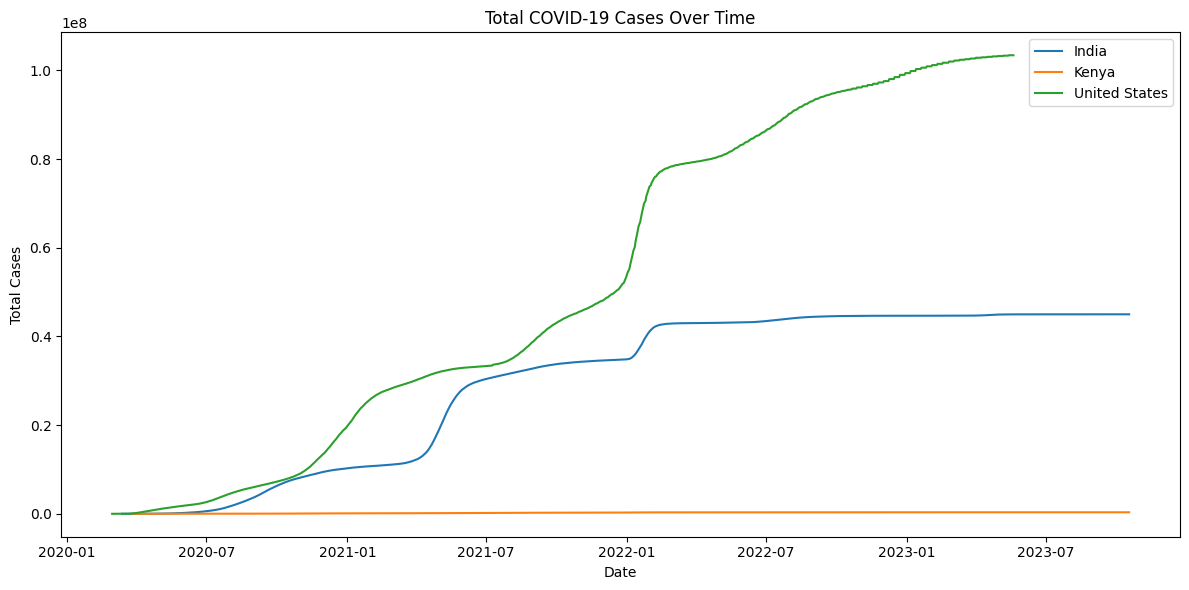

In [25]:
plt.figure(figsize=(12, 6))

for country in ['India', 'Kenya', 'United States']:
    country_data = df[df['location'] == country]
    plt.plot(country_data['date'], country_data['total_cases'], label=country)

plt.title("Total COVID-19 Cases Over Time")
plt.xlabel("Date")
plt.ylabel("Total Cases")
plt.legend()
plt.tight_layout()
plt.show()


# **Plot Total Deaths Over Time**

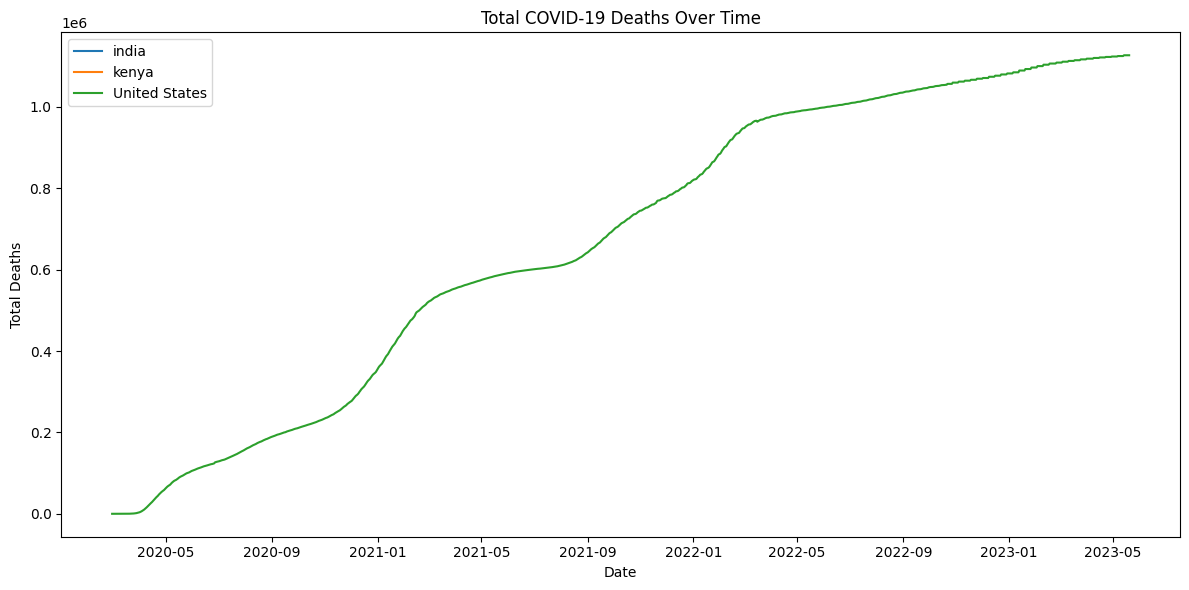

In [26]:
plt.figure(figsize=(12,6))

for country in ['india','kenya','United States']:
    country_data = df[df['location'] == country]
    plt.plot(country_data['date'], country_data['total_deaths'], label= country)


plt.title("Total COVID-19 Deaths Over Time")
plt.xlabel("Date")
plt.ylabel("Total Deaths")
plt.legend()
plt.tight_layout()
plt.show()

# **Compare Daily New Cases Between Countries**

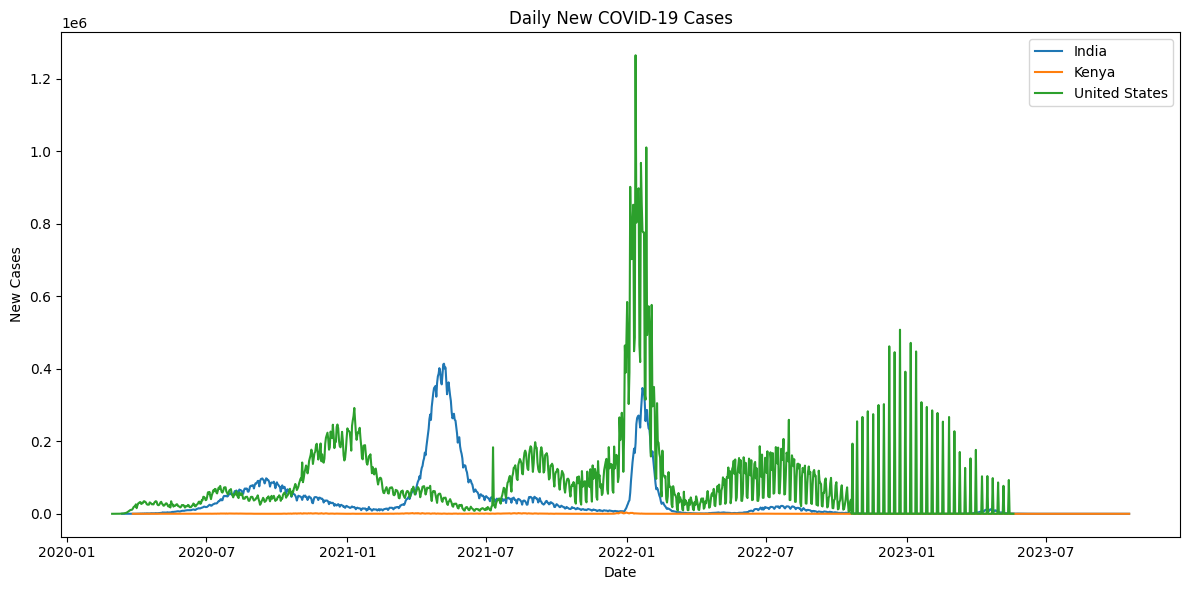

In [27]:
plt.figure(figsize=(12, 6))

for country in ['India', 'Kenya', 'United States']:
    country_data = df[df['location'] == country]
    plt.plot(country_data['date'], country_data['new_cases'], label=country)

plt.title("Daily New COVID-19 Cases")
plt.xlabel("Date")
plt.ylabel("New Cases")
plt.legend()
plt.tight_layout()
plt.show()


# **DEATH RATE**

In [28]:
# Calculate death rate
df['death_rate'] = df['total_deaths'] / df['total_cases']

In [29]:
#df['death_rate'] = df['total_deaths'] / df['total_cases']
print(df[['location', 'date', 'total_cases', 'total_deaths', 'death_rate']].head())


       location       date  total_cases  total_deaths  death_rate
81  Afghanistan 2020-03-24         40.0           1.0    0.025000
82  Afghanistan 2020-03-25         42.0           1.0    0.023810
83  Afghanistan 2020-03-26         74.0           1.0    0.013514
84  Afghanistan 2020-03-27         74.0           1.0    0.013514
85  Afghanistan 2020-03-28         80.0           2.0    0.025000


# **Bar Chart: Top Countries by Total Cases**

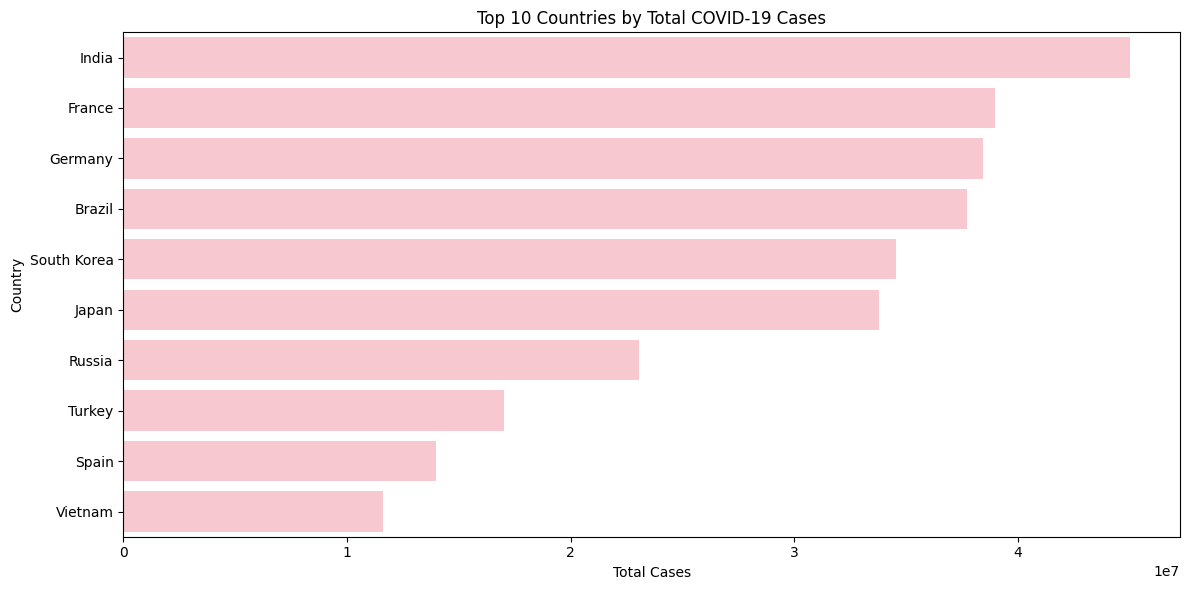

In [30]:
latest = df[df['date'] == df['date'].max()]  # Latest data
top_countries = latest.groupby('location')['total_cases'].max().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, color="pink")
plt.title("Top 10 Countries by Total COVID-19 Cases")
plt.xlabel("Total Cases")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# **Heatmap**

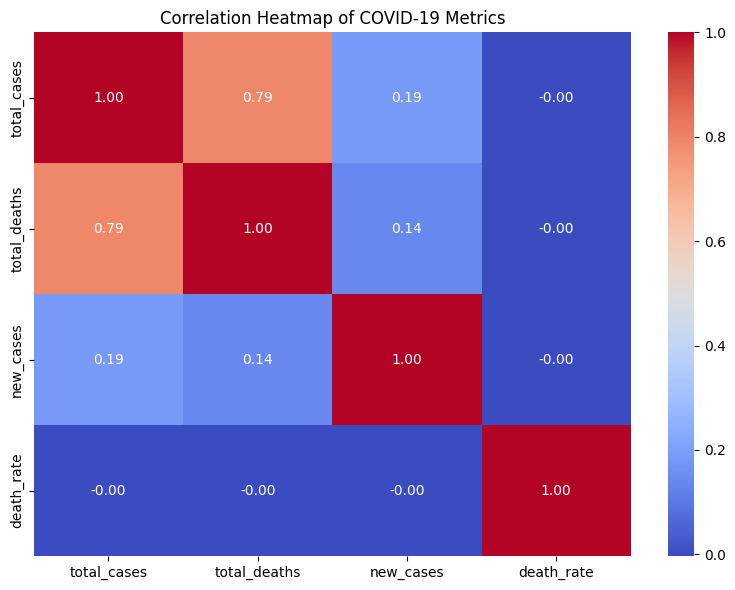

In [31]:
numeric_cols = df[['total_cases', 'total_deaths', 'new_cases', 'death_rate']].dropna()
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap of COVID-19 Metrics")
plt.tight_layout()
plt.show()


# **Visualizing Vaccination Progress**

In [32]:
print(df.columns)

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
countries = ['India', 'United States', 'Brazil', 'France', 'South Africa']

In [37]:
# Convert date to datetime
vacc_df = df[df['location'].isin(countries)].copy()
vacc_df['date'] = pd.to_datetime(vacc_df['date'])

In [38]:
# Get the latest vaccination record for each country
test_vacc = (
    vacc_df.sort_values('date')
    .groupby('location', as_index=False)
    .last()
)

# **Plot Cumulative Vaccinations Over Time**

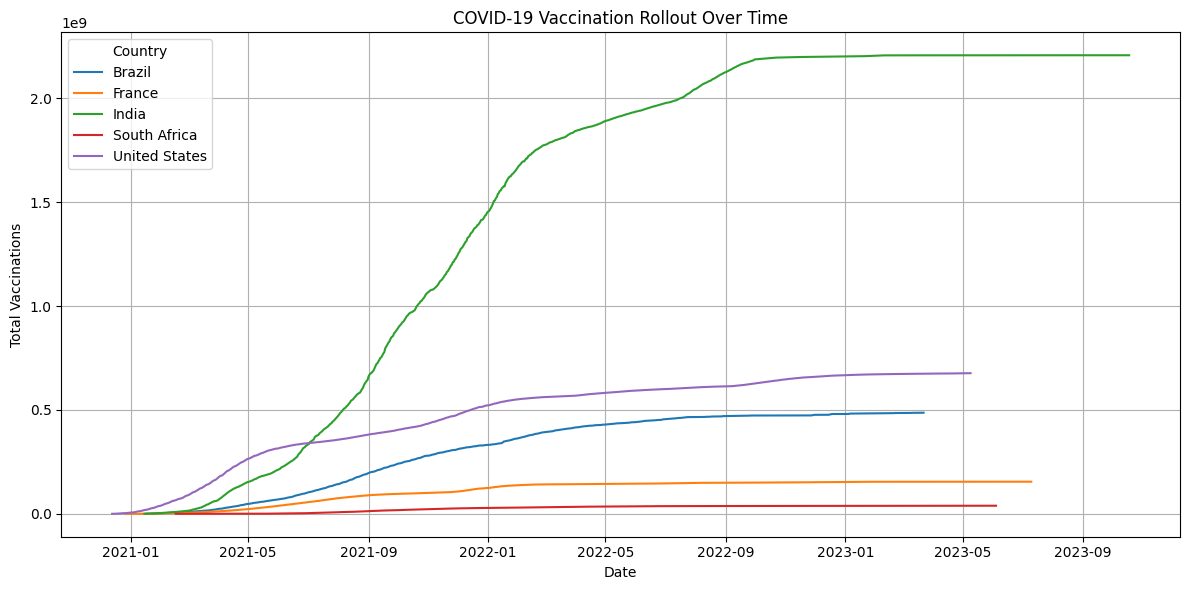

In [39]:
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=vacc_df,
    x='date',
    y='total_vaccinations',
    hue='location'
)
plt.title('COVID-19 Vaccination Rollout Over Time')
plt.xlabel('Date')
plt.ylabel('Total Vaccinations')
plt.legend(title='Country')
plt.grid(True)
plt.tight_layout()
plt.show()


# **Visualizing Vaccination Progress**

In [40]:
# Get the latest vaccination record for each country
latest_vacc = (
    vacc_df.sort_values('date')
    .groupby('location', as_index=False)
    .last()
)


In [41]:
# Calculate vaccination percentage
latest_vacc['vaccinated_pct'] = (
    latest_vacc['people_vaccinated'] / latest_vacc['population'] * 100
)

In [42]:
# Keep only countries with actual data
latest_vacc = latest_vacc.dropna(subset=['vaccinated_pct'])

In [43]:
# Sort by vaccination percentage
latest_vacc = latest_vacc.sort_values('vaccinated_pct', ascending=False)

print(latest_vacc[['location', 'vaccinated_pct']].head(10))

        location  vaccinated_pct
0         Brazil       88.077816
1         France       80.630083
4  United States       79.880368
2          India       72.497768
3   South Africa       40.423081


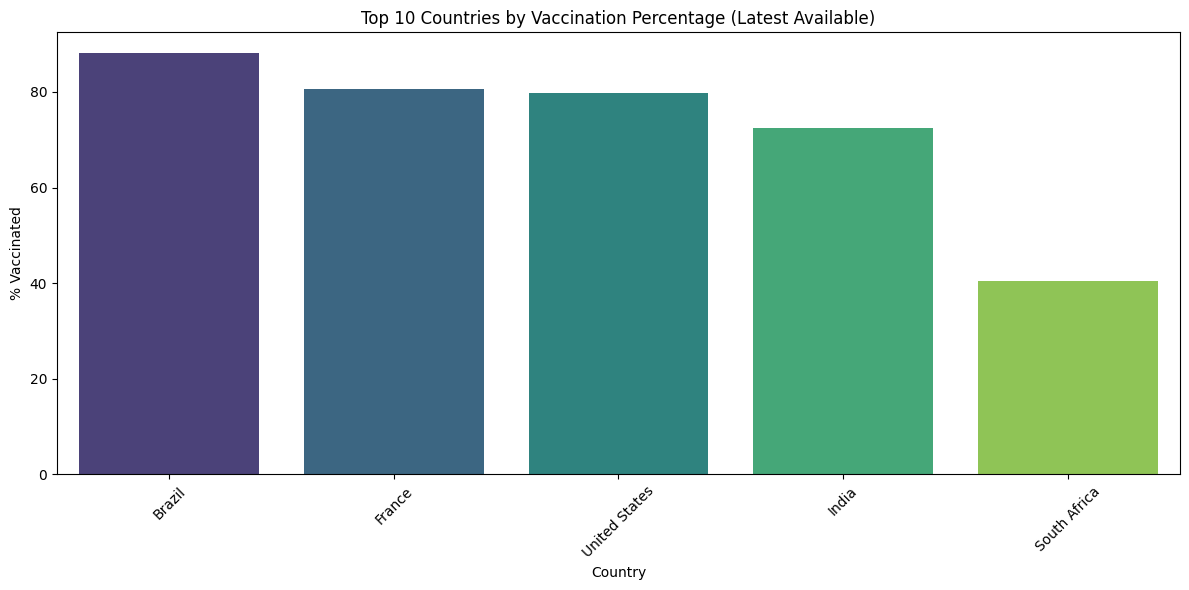

In [44]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=latest_vacc.head(10),
    x='location',
    y='vaccinated_pct',
    hue='location',
    palette='viridis',
    legend=False
)
plt.title('Top 10 Countries by Vaccination Percentage (Latest Available)')
plt.ylabel('% Vaccinated')
plt.xlabel('Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# **`Optional: Build a Choropleth Map`**

In [45]:
pip install plotly


In [46]:
import pandas as pd
import plotly.express as px

# Keep only needed columns
choropleth_df = vacc_df[[ 'location', 'date', 'people_vaccinated', 'population']].dropna()


In [47]:

# Get the latest record per country
choropleth_df = (
    choropleth_df.sort_values('date')
    .groupby('location', as_index=False)
    .last()
)

In [48]:
# Calculate % vaccinated
choropleth_df['vaccinated_pct'] = (choropleth_df['people_vaccinated'] / choropleth_df['population']) * 100

print(choropleth_df[[ 'location', 'vaccinated_pct']].head())


        location  vaccinated_pct
0         Brazil       88.077816
1         France       80.630083
2          India       72.497768
3   South Africa       40.423081
4  United States       79.880368


In [49]:
# Plot Choropleth using country names
fig = px.choropleth(
    choropleth_df,
    locations='location',
    locationmode='country names',
    color='vaccinated_pct',
    hover_name='location',
    color_continuous_scale='Viridis',
    title='Global COVID-19 Vaccination Rates (Latest Available)',
    projection='natural earth'
)

fig.update_layout(
    coloraxis_colorbar=dict(
        title='% Vaccinated'
    )
)

fig.show()
